In [13]:
import typing

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import scipy.interpolate
import scipy.ndimage
import scipy.spatial
import skimage.data
import skimage.feature

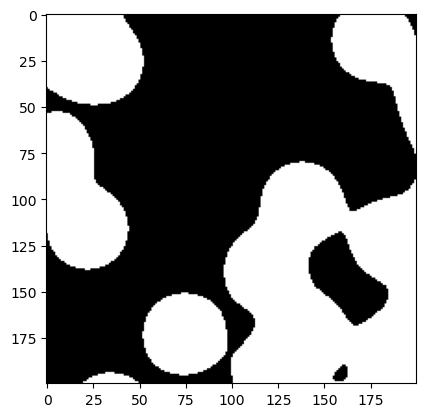

In [14]:
def get_reference():
    img = skimage.data.binary_blobs(rng=0)[:200, :200]
    img = (img / img.max() * 255).round().clip(0, 255).astype('uint8')
    return img


reference = get_reference()
plt.imshow(reference, cmap='gray')
plt.show()

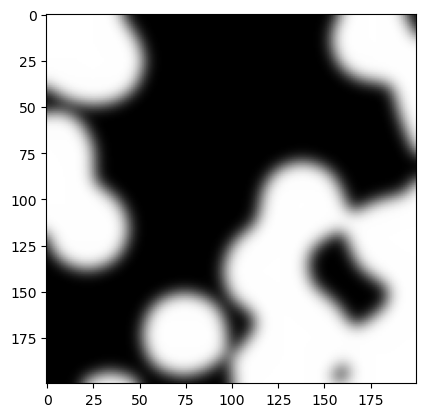

In [15]:
def get_blurry(img, sigma=4):
    return scipy.ndimage.gaussian_filter(img, sigma=sigma, mode='nearest')


blurry = get_blurry(reference)
plt.imshow(blurry, cmap='gray')
plt.show()

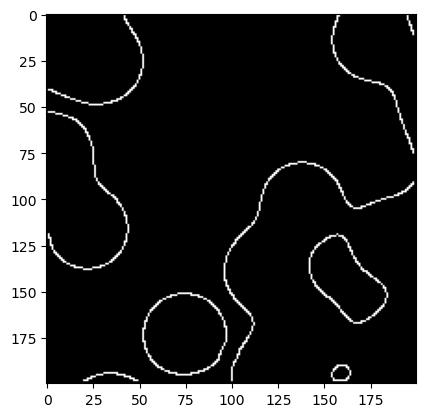

In [ ]:
def get_edges(img, **kwargs):
    return skimage.feature.canny(img, mode='nearest', **kwargs)


edge_map = get_edges(blurry)
plt.imshow(edge_map, cmap='gray')
plt.show()

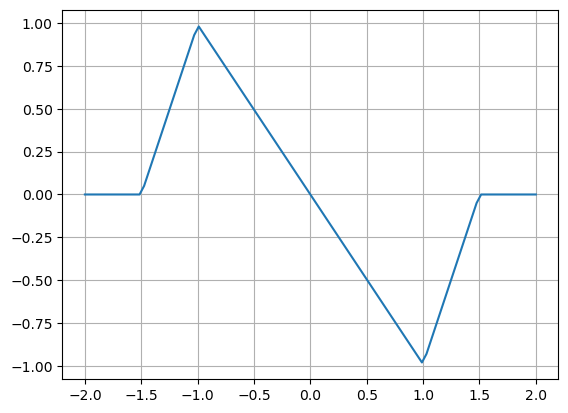

In [17]:
def piecewise_linear_displacement_function(x: float, a: float, steepness: float = 0.99):
    return steepness * np.where(
        np.abs(x) <= a,
        -x,
        np.where(
            np.abs(x) <= 3/2 * a,
            -(3*a - 2*np.abs(x)) * np.sign(x),
            0
        )
    )


x = np.linspace(-2, 2, num=100)
plt.plot(x, piecewise_linear_displacement_function(x, 1))
plt.grid()
plt.show()

In [18]:
def convert_array_to_point_cloud(array):
    '''Преобразовать массив размера HxW в 2 массива:
    - Координаты (H*W)x2
    - Значения (H*W)
    '''
    ix = np.indices(array.shape)
    coords = np.moveaxis(np.indices(array.shape), 0, -1).astype('float')
    values = array.copy()
    
    return coords, values

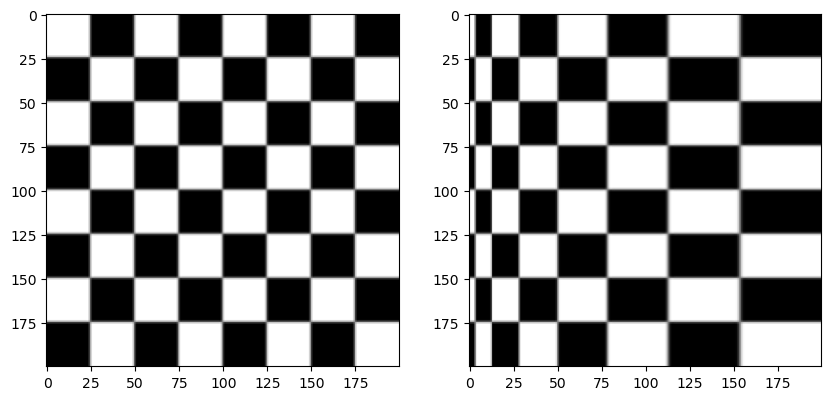

In [19]:
def interpolate_on_regular_grid(
    image: npt.NDArray,
    old_grid: npt.NDArray,
    new_grid: typing.Optional[npt.NDArray] = None,
    interpolation_method: typing.Literal['linear', 'nearest', 'cubic'] = 'linear',
    interpolation_kwargs: typing.Optional[dict] = None,
    fast_interpolation: bool = False,
    edge_map: typing.Optional[npt.NDArray] = None
):
    if new_grid is None:
        new_grid = np.moveaxis(np.indices(image.shape), 0, -1)

    # Если писать `interpolation_kwargs={}` при объявлении функции, 
    # то этот словарь (список и т.д.) будет один на все её вызовы 
    # и будет сохранять содержимое, если меняется внутри функции
    if interpolation_kwargs is None:
        interpolation_kwargs = {}

    old_grid = old_grid.reshape(-1, 2)
    new_grid = new_grid.reshape(-1, 2)
    data = image.ravel()  # Разницу между flatten(), ravel() и reshape() см. тут: https://stackoverflow.com/a/28930580
    
    if interpolation_method == 'rbf':
        interpolator = scipy.interpolate.RBFInterpolator(
            old_grid,
            data,
            **interpolation_kwargs,
        )
        res = interpolator(new_grid).reshape(image.shape)
        
    else:
        if not fast_interpolation:
            res = scipy.interpolate.griddata(
                points=old_grid,
                values=data,
                xi=new_grid,
                method=interpolation_method,
            ).reshape(image.shape)
            
        else:
            working_area_mask = np.isclose(np.linalg.norm(new_grid - old_grid, ord=2, axis=-1), 0)
            res = data.copy()
            res[working_area_mask] = scipy.interpolate.griddata(
                points=old_grid,
                values=data,
                xi=new_grid[working_area_mask],
                method=interpolation_method,
            )
            res = res.reshape(image.shape)
    
    nan_mask = np.isnan(res)
    res[nan_mask] = image[nan_mask]
    if edge_map is not None:
        edge_mask = edge_map > 0
        res[edge_map] = image[edge_mask]
    res = res.clip(image.min(), image.max())
    
    return res


image = skimage.data.checkerboard()
regular_grid = np.moveaxis(np.indices(image.shape), 0, -1).astype('float')
regular_grid[:, :, 1] /= regular_grid[:, :, 1].max()
modified_grid = regular_grid.copy()
modified_grid[:, :, 1] = modified_grid[:, :, 1] ** 2
warped_image = interpolate_on_regular_grid(
    image=image,
    old_grid=modified_grid,
    new_grid=regular_grid,
    interpolation_method='cubic',
    interpolation_kwargs={},
    fast_interpolation=False,
)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(warped_image, cmap='gray')
plt.show()

In [20]:
def warp_grid(
    edge_map: np.typing.NDArray,
    distance_limit: float,
    displacement_function: typing.Callable,
    displacement_function_kwargs: typing.Optional[dict] = None,
    amplification: float = 1.0,
):
    if displacement_function_kwargs is None:
        displacement_function_kwargs = {}

    pixel_coords, edge_map_values = convert_array_to_point_cloud(edge_map)  # (H*W)x2, (HW)
    edge_mask = edge_map_values > 0

    edge_kd_tree = scipy.spatial.KDTree(pixel_coords[edge_mask])
    
    # Тут можно проверять только "неконтуры", но потом будет морока со стыковкой масок
    # Например, нельзя делать `array[mask1][mask2] = new_data`: https://stackoverflow.com/a/38768993
    distance_to_edge, closest_edge_pixel_ix = edge_kd_tree.query(pixel_coords, k=1, workers=-1)
    distance_mask = (distance_to_edge > 0) & (distance_to_edge <= distance_limit)

    from_edge_direction = pixel_coords[distance_mask] - pixel_coords[edge_mask][closest_edge_pixel_ix[distance_mask]]
    from_edge_direction /= np.linalg.norm(from_edge_direction, ord=2, axis=-1, keepdims=True)
    displacement = from_edge_direction * displacement_function(
        x=distance_to_edge[distance_mask],
        **displacement_function_kwargs
    )[..., np.newaxis] * amplification
    
    warped_grid = pixel_coords.copy()
    warped_grid[distance_mask] += displacement
    
    return warped_grid, pixel_coords

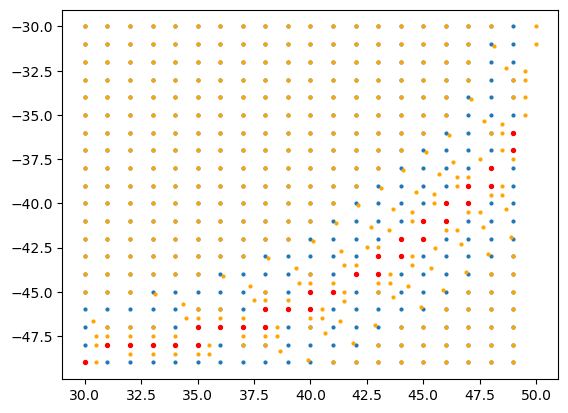

In [21]:
warped_grid, regular_grid = warp_grid(
    edge_map=edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 2},
    amplification=0.5
)

warped_grid = warped_grid[30:50, 30:50, :]
regular_grid = regular_grid[30:50, 30:50, :]
edges = edge_map[30:50, 30:50]

N = 1
s = 4
plt.scatter(regular_grid[::N, ::N, 1].ravel(), -regular_grid[::N, ::N, 0].ravel(), s=s)
plt.scatter(warped_grid[::N, ::N, 1].ravel(), -warped_grid[::N, ::N, 0].ravel(), s=s, c='orange')
plt.scatter(warped_grid[:, :, 1][edges], -warped_grid[:, :, 0][edges], s=s*2, c='red')

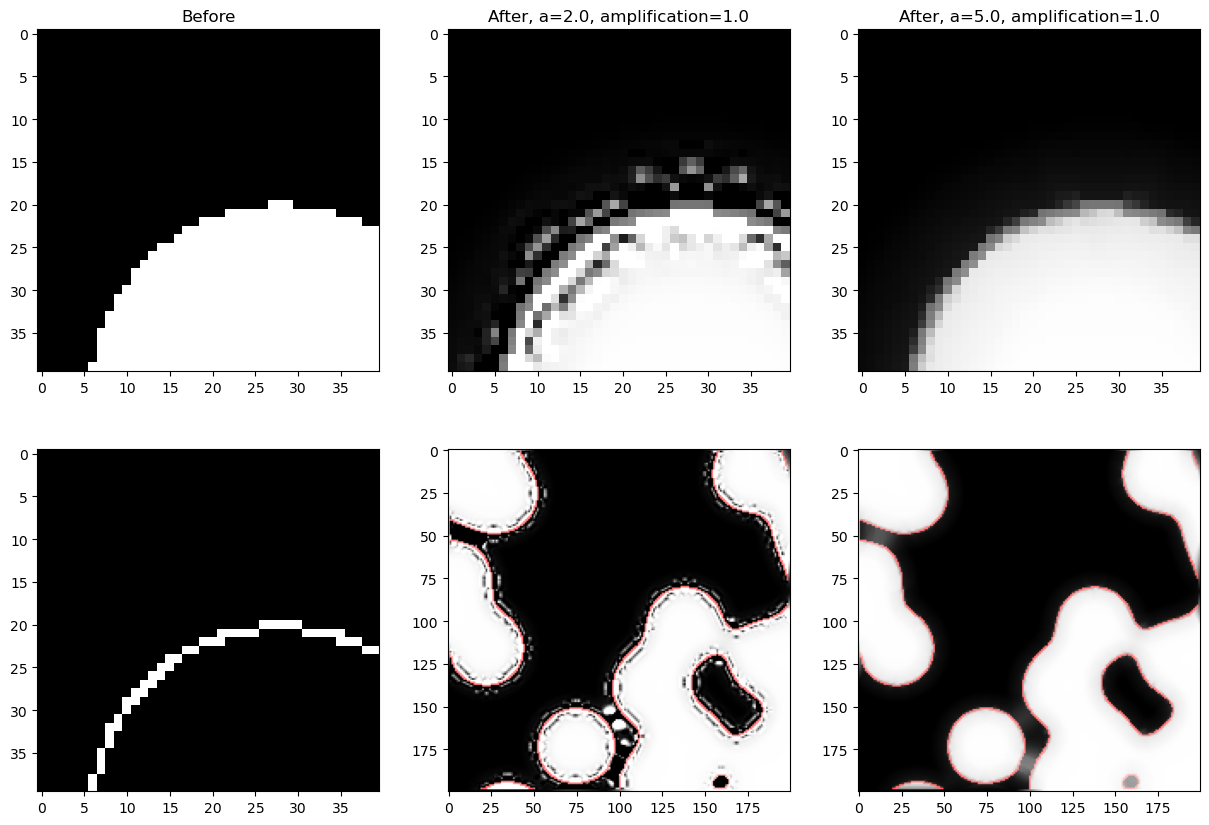

In [22]:
warped_grid, regular_grid = warp_grid(
    edge_map=edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
warped_image1 = interpolate_on_regular_grid(
    image=blurry,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='cubic',
    interpolation_kwargs={},
    fast_interpolation=False
)

warped_grid, regular_grid = warp_grid(
    edge_map=edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
warped_image2 = interpolate_on_regular_grid(
    image=blurry,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)
before = np.tile(blurry[:, :, np.newaxis], (1, 1, 3))  # RGB
after1 = np.tile(warped_image1[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')  # RGB
after2 = np.tile(warped_image2[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')  # RGB
edge_lines = np.stack([edge_map] + [np.zeros_like(edge_map)] * 2, axis=-1) * 255

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(reference[60:100, 110:150], cmap='grey')
plt.title('Before')
plt.subplot(2, 3, 4)
# plt.imshow(np.maximum(before, edge_lines))
plt.imshow(edge_map[60:100, 110:150], cmap='grey')

plt.subplot(2, 3, 2)
plt.imshow(after1[60:100, 110:150])
plt.title('After, a=2.0, amplification=1.0')
plt.subplot(2, 3, 5)
plt.imshow(np.maximum(after1, edge_lines))

plt.subplot(2, 3, 3)
plt.imshow(after2[60:100, 110:150])
plt.title('After, a=5.0, amplification=1.0')
plt.subplot(2, 3, 6)
plt.imshow(np.maximum(after2, edge_lines))

plt.show()

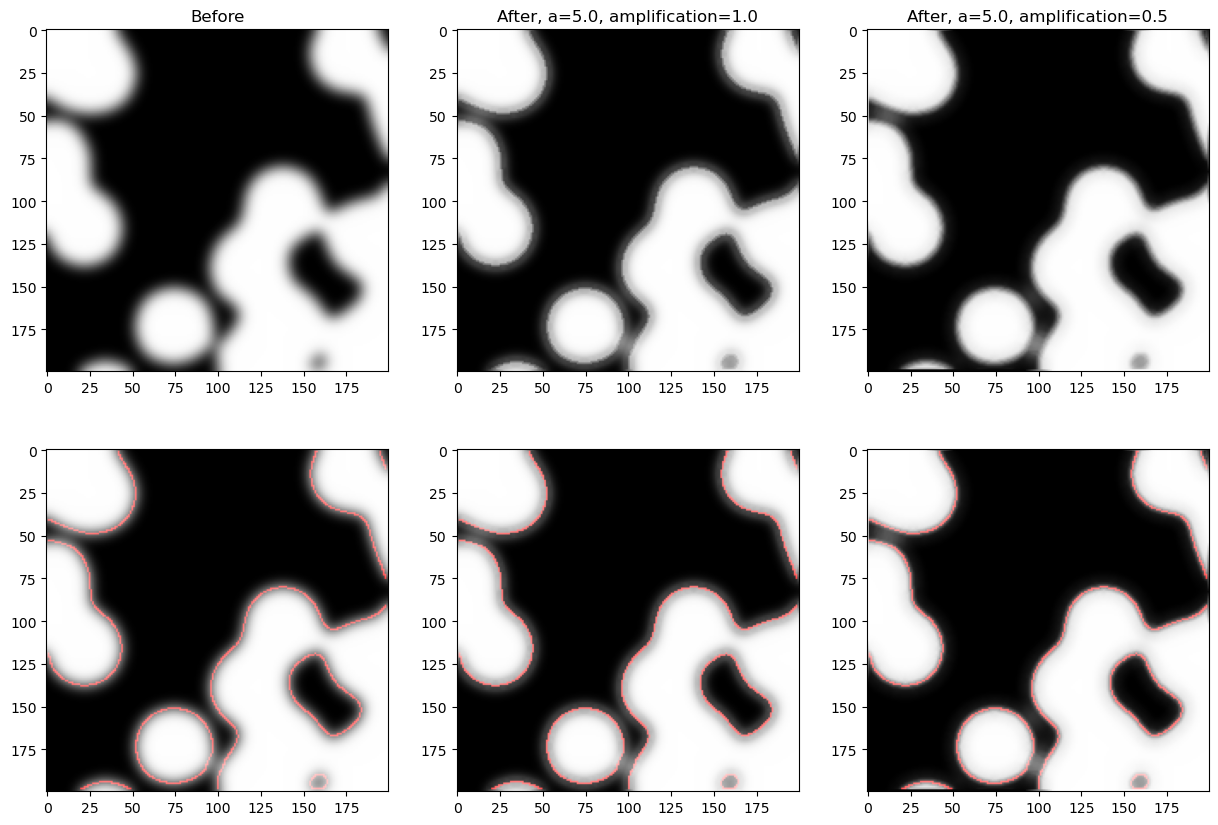

(200, 200, 3) (200, 200, 3)


In [ ]:
warped_grid, regular_grid = warp_grid(
    edge_map=edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
warped_image1 = interpolate_on_regular_grid(
    image=blurry,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False,
)

warped_grid, regular_grid = warp_grid(
    edge_map=edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=0.5
)
warped_image2 = interpolate_on_regular_grid(
    image=blurry,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False,
)

before = np.tile(blurry[:, :, np.newaxis], (1, 1, 3))  # RGB
after1 = np.tile(warped_image1[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')  # RGB
after2 = np.tile(warped_image2[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')  # RGB
edge_lines = np.stack([edge_map] + [np.zeros_like(edge_map)] * 2, axis=-1) * 255

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(before)
plt.title('Before')
plt.subplot(2, 3, 4)
plt.imshow(np.maximum(before, edge_lines))

plt.subplot(2, 3, 2)
plt.imshow(after1)
plt.title('After, a=5.0, amplification=1.0')
plt.subplot(2, 3, 5)
plt.imshow(np.maximum(after1, edge_lines))

plt.subplot(2, 3, 3)
plt.imshow(after2)
plt.title('After, a=5.0, amplification=0.5')
plt.subplot(2, 3, 6)
plt.imshow(np.maximum(after2, edge_lines))

plt.show()

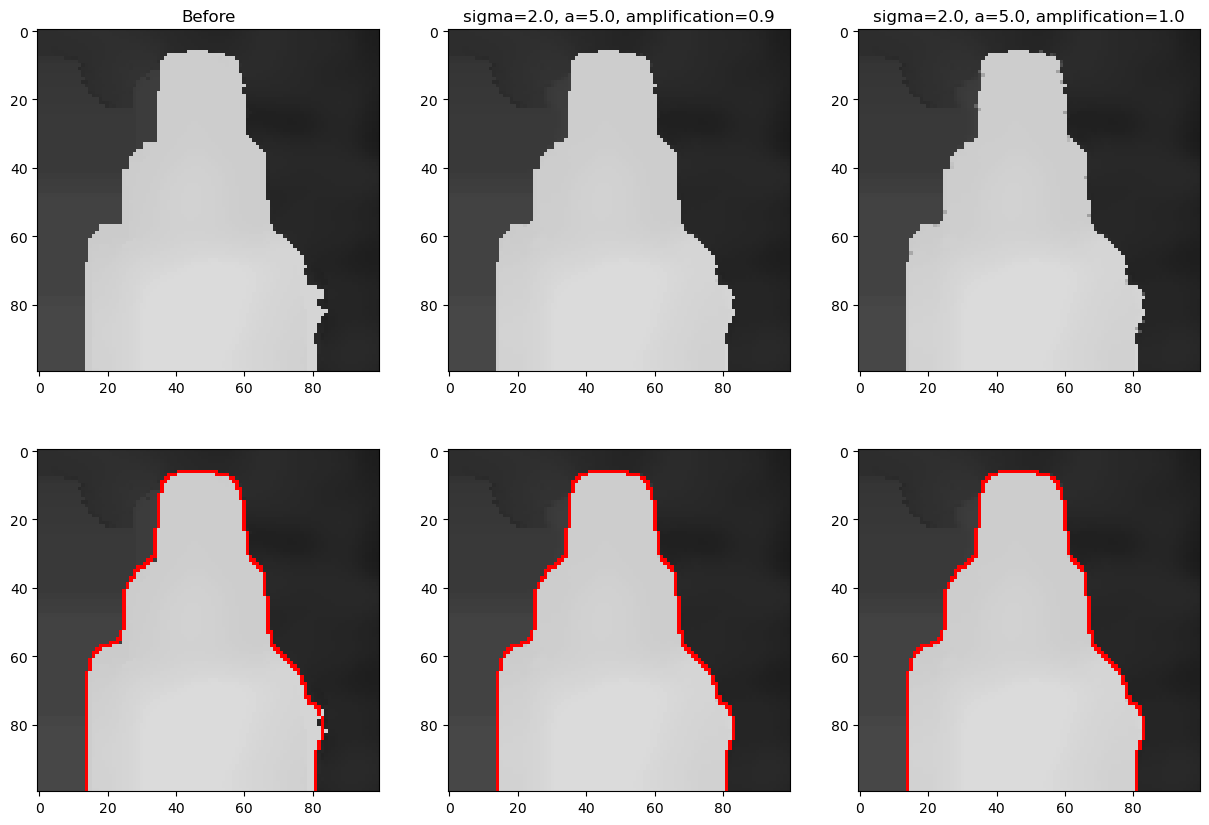

In [ ]:
# SIGMA 2 AMPL 0.9 1.0 PATCH
from skimage import io, filters, color
my_img = io.imread('no_decimation_9_Depth.png')
if len(my_img.shape) == 3:
    my_img = color.rgb2gray(my_img)
my_img = (my_img / my_img.max() * 255).round().clip(0, 255).astype('uint8')
my_blurry = get_blurry(my_img, sigma=2)
my_edge_map = get_edges(my_blurry)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=0.9
)
my_warped_image1 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
my_warped_image2 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)

my_img = np.tile(my_img[150:250, 220:320, np.newaxis], (1, 1, 3))
my_warped_image1 = np.tile(my_warped_image1[150:250, 220:320, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_warped_image2 = np.tile(my_warped_image2[150:250, 220:320, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_edge_map = my_edge_map[150:250, 220:320]
img_w_edges = my_img.copy()
img_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg1_w_edges = my_warped_image1.copy()
wimg1_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg2_w_edges = my_warped_image1.copy()
wimg2_w_edges[my_edge_map > 0] = [255, 0, 0]

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(my_img, cmap='gray')
plt.title('Before')
plt.subplot(2, 3, 4)
plt.imshow(img_w_edges)

plt.subplot(2, 3, 2)
plt.imshow(my_warped_image1, cmap='gray')
plt.title('sigma=2.0, a=5.0, amplification=0.9')
plt.subplot(2, 3, 5)
plt.imshow(wimg1_w_edges)

plt.subplot(2, 3, 3)
plt.imshow(my_warped_image2, cmap='gray')
plt.title('sigma=2.0, a=5.0, amplification=1.0')
plt.subplot(2, 3, 6)
plt.imshow(wimg2_w_edges)

plt.show()

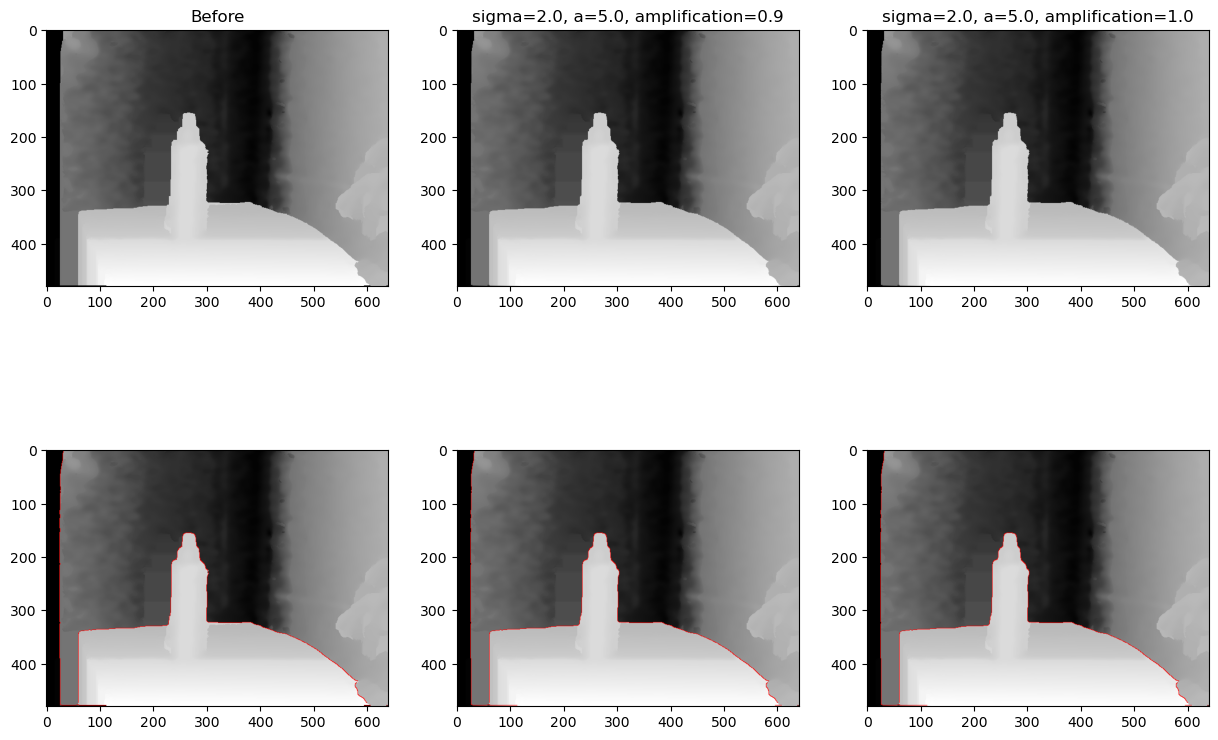

In [ ]:
# SIGMA 2 AMPL 0.9 1.0 FULL
from skimage import io, filters, color
my_img = io.imread('no_decimation_9_Depth.png')
if len(my_img.shape) == 3:
    my_img = color.rgb2gray(my_img)
my_img = (my_img / my_img.max() * 255).round().clip(0, 255).astype('uint8')
my_blurry = get_blurry(my_img, sigma=2)
my_edge_map = get_edges(my_blurry)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=0.9
)
my_warped_image1 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
my_warped_image2 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)

my_img = np.tile(my_img[:, :, np.newaxis], (1, 1, 3))
my_warped_image1 = np.tile(my_warped_image1[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_warped_image2 = np.tile(my_warped_image2[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_edge_map = my_edge_map[:, :]
img_w_edges = my_img.copy()
img_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg1_w_edges = my_warped_image1.copy()
wimg1_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg2_w_edges = my_warped_image1.copy()
wimg2_w_edges[my_edge_map > 0] = [255, 0, 0]

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(my_img, cmap='gray')
plt.title('Before')
plt.subplot(2, 3, 4)
plt.imshow(img_w_edges)

plt.subplot(2, 3, 2)
plt.imshow(my_warped_image1, cmap='gray')
plt.title('sigma=2.0, a=5.0, amplification=0.9')
plt.subplot(2, 3, 5)
plt.imshow(wimg1_w_edges)

plt.subplot(2, 3, 3)
plt.imshow(my_warped_image2, cmap='gray')
plt.title('sigma=2.0, a=5.0, amplification=1.0')
plt.subplot(2, 3, 6)
plt.imshow(wimg2_w_edges)

plt.show()

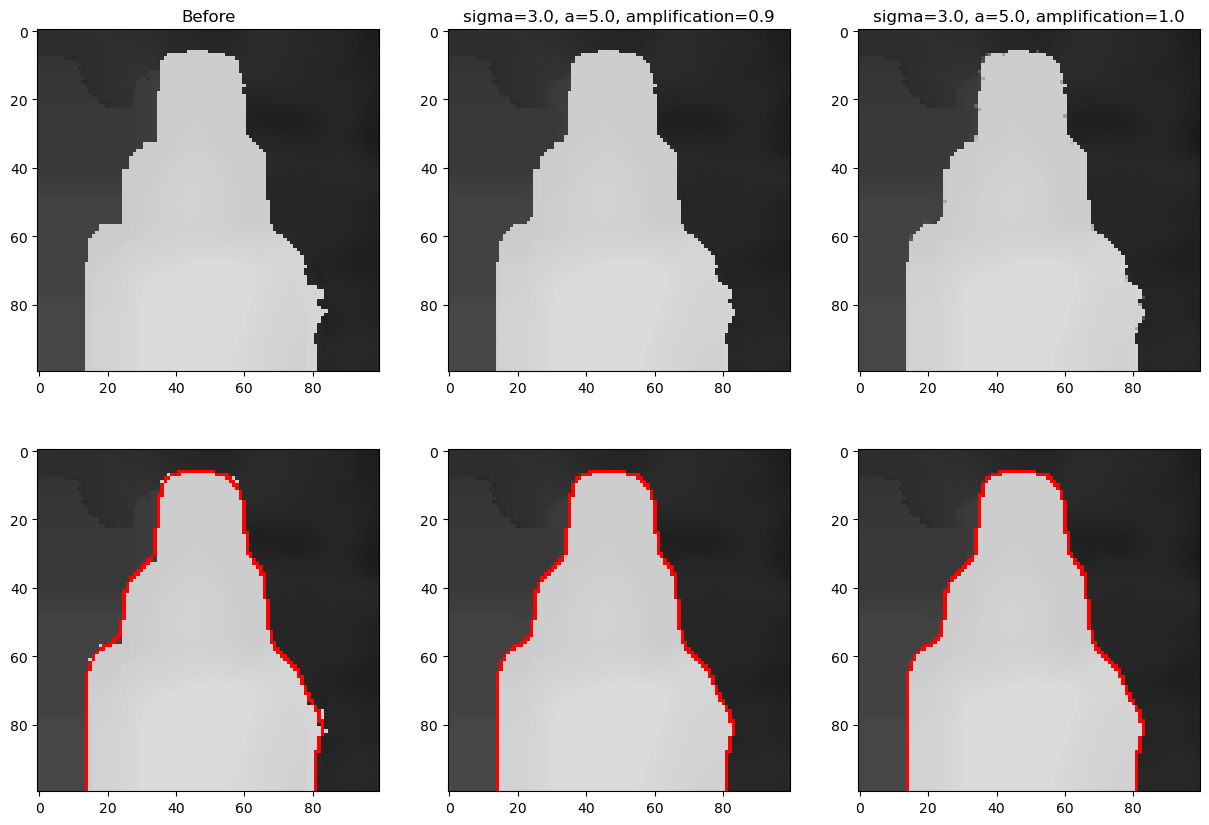

In [39]:
# SIGMA 3 AMPL 0.9 1.0 PATCH
from skimage import io, filters, color
my_img = io.imread('no_decimation_9_Depth.png')
if len(my_img.shape) == 3:
    my_img = color.rgb2gray(my_img)
my_img = (my_img / my_img.max() * 255).round().clip(0, 255).astype('uint8')
my_blurry = get_blurry(my_img, sigma=3)
my_edge_map = get_edges(my_blurry)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=0.9
)
my_warped_image1 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
my_warped_image2 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)

my_img = np.tile(my_img[150:250, 220:320, np.newaxis], (1, 1, 3))
my_warped_image1 = np.tile(my_warped_image1[150:250, 220:320, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_warped_image2 = np.tile(my_warped_image2[150:250, 220:320, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_edge_map = my_edge_map[150:250, 220:320]
img_w_edges = my_img.copy()
img_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg1_w_edges = my_warped_image1.copy()
wimg1_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg2_w_edges = my_warped_image1.copy()
wimg2_w_edges[my_edge_map > 0] = [255, 0, 0]

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(my_img, cmap='gray')
plt.title('Before')
plt.subplot(2, 3, 4)
plt.imshow(img_w_edges)

plt.subplot(2, 3, 2)
plt.imshow(my_warped_image1, cmap='gray')
plt.title('sigma=3.0, a=5.0, amplification=0.9')
plt.subplot(2, 3, 5)
plt.imshow(wimg1_w_edges)

plt.subplot(2, 3, 3)
plt.imshow(my_warped_image2, cmap='gray')
plt.title('sigma=3.0, a=5.0, amplification=1.0')
plt.subplot(2, 3, 6)
plt.imshow(wimg2_w_edges)

plt.show()

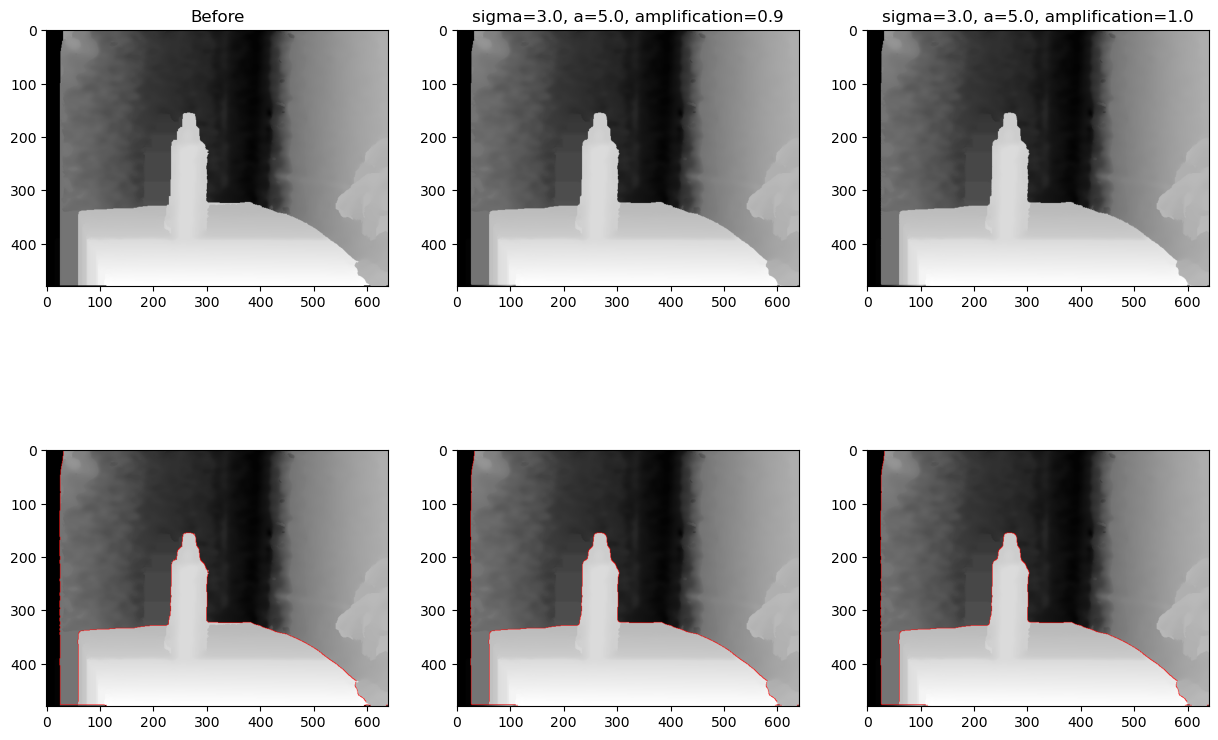

In [40]:
# SIGMA 3 AMPL 0.9 1.0 FULL
from skimage import io, filters, color
my_img = io.imread('no_decimation_9_Depth.png')
if len(my_img.shape) == 3:
    my_img = color.rgb2gray(my_img)
my_img = (my_img / my_img.max() * 255).round().clip(0, 255).astype('uint8')
my_blurry = get_blurry(my_img, sigma=3)
my_edge_map = get_edges(my_blurry)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=0.9
)
my_warped_image1 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
my_warped_image2 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)

my_img = np.tile(my_img[:, :, np.newaxis], (1, 1, 3))
my_warped_image1 = np.tile(my_warped_image1[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_warped_image2 = np.tile(my_warped_image2[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_edge_map = my_edge_map[:, :]
img_w_edges = my_img.copy()
img_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg1_w_edges = my_warped_image1.copy()
wimg1_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg2_w_edges = my_warped_image1.copy()
wimg2_w_edges[my_edge_map > 0] = [255, 0, 0]

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(my_img, cmap='gray')
plt.title('Before')
plt.subplot(2, 3, 4)
plt.imshow(img_w_edges)

plt.subplot(2, 3, 2)
plt.imshow(my_warped_image1, cmap='gray')
plt.title('sigma=3.0, a=5.0, amplification=0.9')
plt.subplot(2, 3, 5)
plt.imshow(wimg1_w_edges)

plt.subplot(2, 3, 3)
plt.imshow(my_warped_image2, cmap='gray')
plt.title('sigma=3.0, a=5.0, amplification=1.0')
plt.subplot(2, 3, 6)
plt.imshow(wimg2_w_edges)

plt.show()

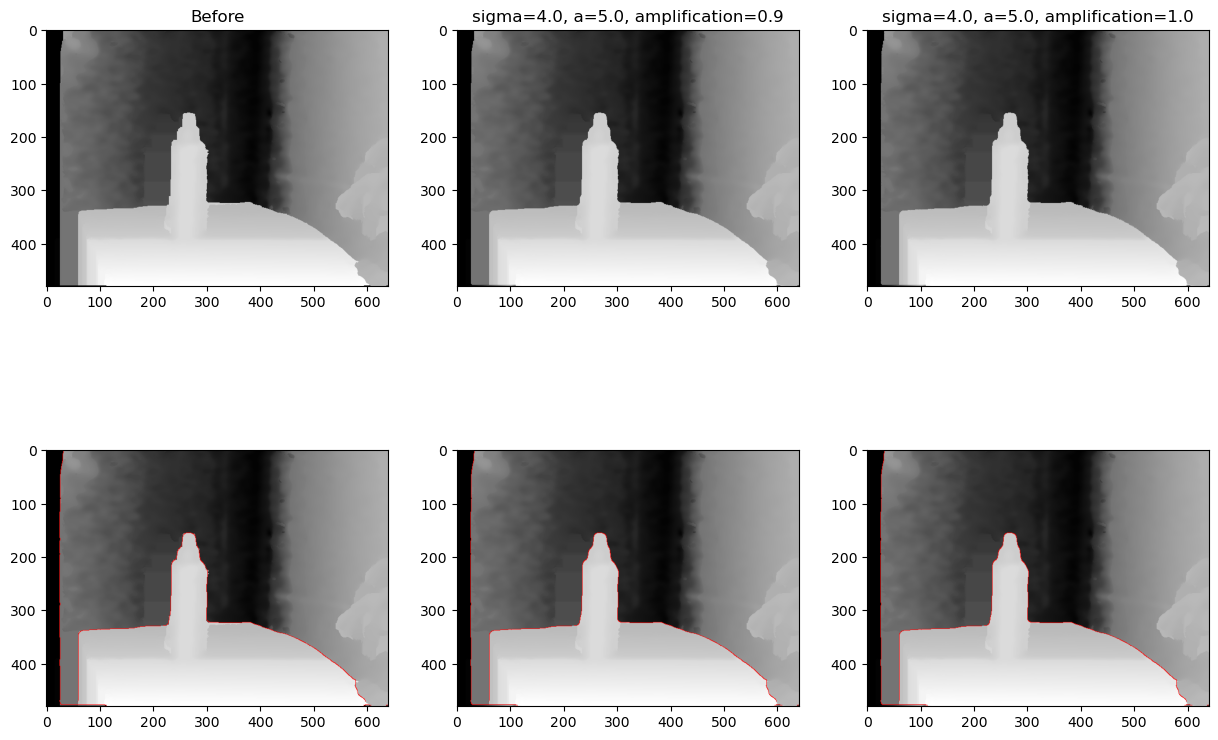

In [41]:
# SIGMA 4 AMPL 0.9 1.0 FULL
from skimage import io, filters, color
my_img = io.imread('no_decimation_9_Depth.png')
if len(my_img.shape) == 3:
    my_img = color.rgb2gray(my_img)
my_img = (my_img / my_img.max() * 255).round().clip(0, 255).astype('uint8')
my_blurry = get_blurry(my_img, sigma=4)
my_edge_map = get_edges(my_blurry)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=0.9
)
my_warped_image1 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
my_warped_image2 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)

my_img = np.tile(my_img[:, :, np.newaxis], (1, 1, 3))
my_warped_image1 = np.tile(my_warped_image1[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_warped_image2 = np.tile(my_warped_image2[:, :, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_edge_map = my_edge_map[:, :]
img_w_edges = my_img.copy()
img_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg1_w_edges = my_warped_image1.copy()
wimg1_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg2_w_edges = my_warped_image1.copy()
wimg2_w_edges[my_edge_map > 0] = [255, 0, 0]

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(my_img, cmap='gray')
plt.title('Before')
plt.subplot(2, 3, 4)
plt.imshow(img_w_edges)

plt.subplot(2, 3, 2)
plt.imshow(my_warped_image1, cmap='gray')
plt.title('sigma=4.0, a=5.0, amplification=0.9')
plt.subplot(2, 3, 5)
plt.imshow(wimg1_w_edges)

plt.subplot(2, 3, 3)
plt.imshow(my_warped_image2, cmap='gray')
plt.title('sigma=4.0, a=5.0, amplification=1.0')
plt.subplot(2, 3, 6)
plt.imshow(wimg2_w_edges)

plt.show()

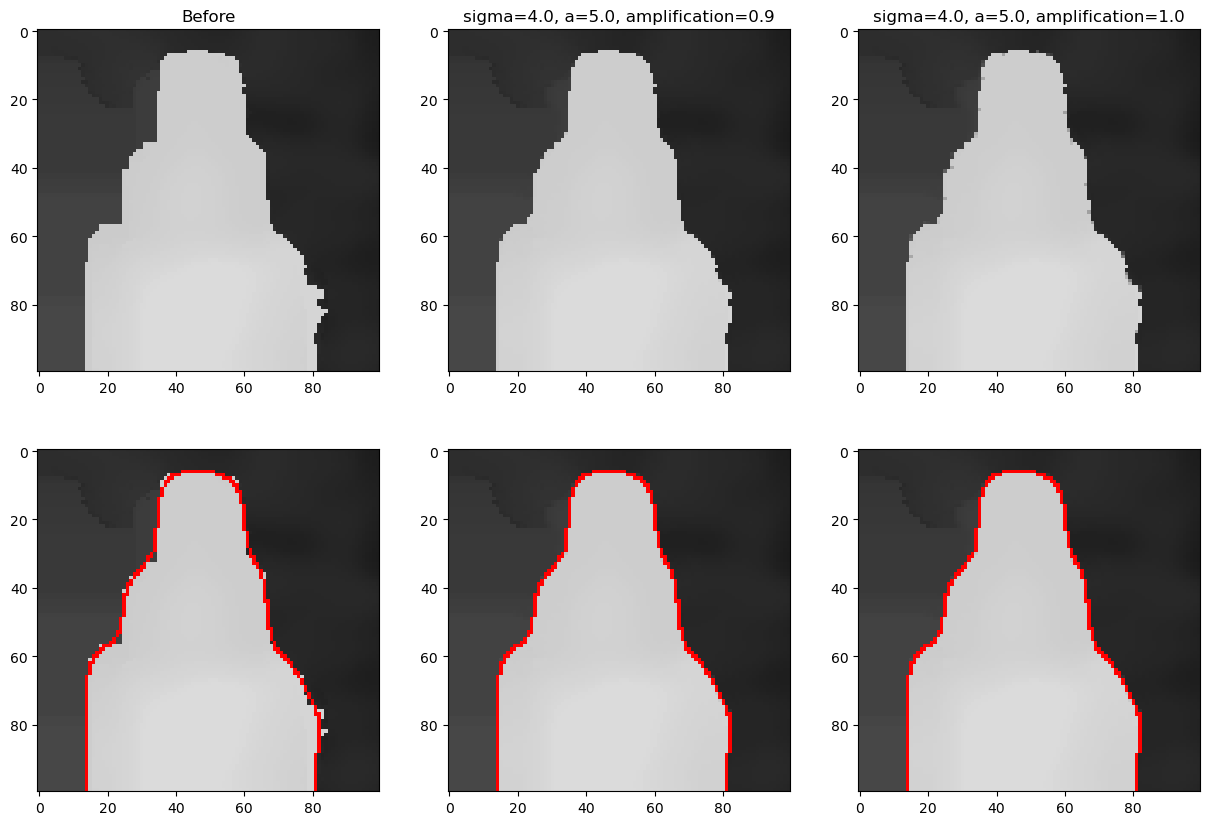

In [42]:
# SIGMA 4 AMPL 0.9 1.0 PATCH
from skimage import io, filters, color
my_img = io.imread('no_decimation_9_Depth.png')
if len(my_img.shape) == 3:
    my_img = color.rgb2gray(my_img)
my_img = (my_img / my_img.max() * 255).round().clip(0, 255).astype('uint8')
my_blurry = get_blurry(my_img, sigma=4)
my_edge_map = get_edges(my_blurry)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=0.9
)
my_warped_image1 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)
warped_grid, regular_grid = warp_grid(
    edge_map=my_edge_map,
    distance_limit=1e6,
    displacement_function=piecewise_linear_displacement_function,
    displacement_function_kwargs={'a': 5.0},
    amplification=1.0
)
my_warped_image2 = interpolate_on_regular_grid(
    image=my_img,
    old_grid=warped_grid,
    new_grid=regular_grid,
    interpolation_method='linear',
    interpolation_kwargs={},
    fast_interpolation=False
)

my_img = np.tile(my_img[150:250, 220:320, np.newaxis], (1, 1, 3))
my_warped_image1 = np.tile(my_warped_image1[150:250, 220:320, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_warped_image2 = np.tile(my_warped_image2[150:250, 220:320, np.newaxis], (1, 1, 3)).round().astype('uint8')
my_edge_map = my_edge_map[150:250, 220:320]
img_w_edges = my_img.copy()
img_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg1_w_edges = my_warped_image1.copy()
wimg1_w_edges[my_edge_map > 0] = [255, 0, 0]
wimg2_w_edges = my_warped_image1.copy()
wimg2_w_edges[my_edge_map > 0] = [255, 0, 0]

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(my_img, cmap='gray')
plt.title('Before')
plt.subplot(2, 3, 4)
plt.imshow(img_w_edges)

plt.subplot(2, 3, 2)
plt.imshow(my_warped_image1, cmap='gray')
plt.title('sigma=4.0, a=5.0, amplification=0.9')
plt.subplot(2, 3, 5)
plt.imshow(wimg1_w_edges)

plt.subplot(2, 3, 3)
plt.imshow(my_warped_image2, cmap='gray')
plt.title('sigma=4.0, a=5.0, amplification=1.0')
plt.subplot(2, 3, 6)
plt.imshow(wimg2_w_edges)

plt.show()

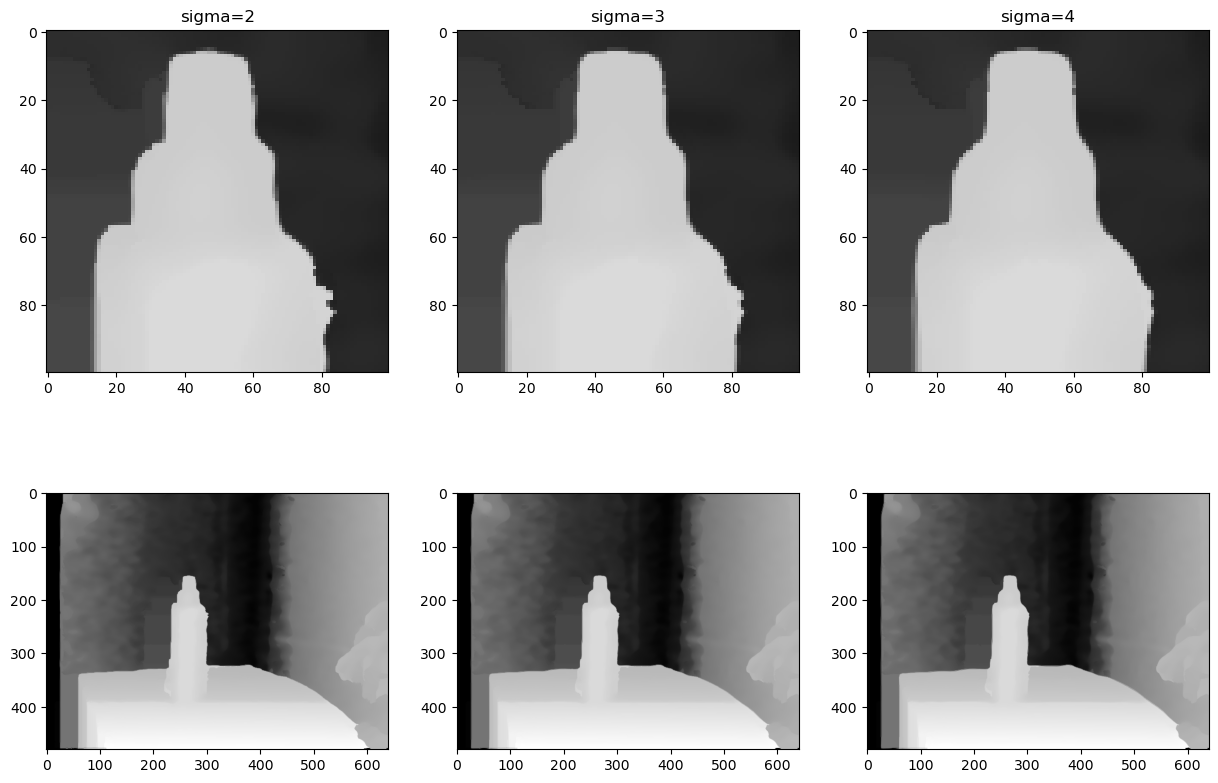

In [46]:
sigma2 = io.imread('test9sigma2.png')
sigma3 = io.imread('test9sigma3.png')
sigma4 = io.imread('test9sigma4.png')

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(sigma2[150:250, 220:320])
plt.title('sigma=2')
plt.subplot(2, 3, 4)
plt.imshow(sigma2, cmap='gray')

plt.subplot(2, 3, 2)
plt.imshow(sigma3[150:250, 220:320])
plt.title('sigma=3')
plt.subplot(2, 3, 5)
plt.imshow(sigma3, cmap='gray')

plt.subplot(2, 3, 3)
plt.imshow(sigma4[150:250, 220:320])
plt.title('sigma=4')
plt.subplot(2, 3, 6)
plt.imshow(sigma4, cmap='gray')

plt.show()

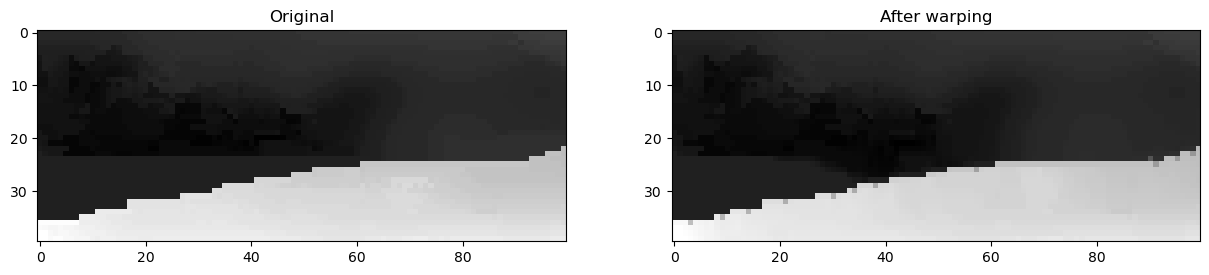

In [ ]:
patch = (slice(380,420), slice(150,250))
patch_orig = my_img[patch]
patch_warped = my_warped_image[patch]
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(patch_orig, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("After warping")
plt.imshow(patch_warped, cmap='gray')
plt.show()

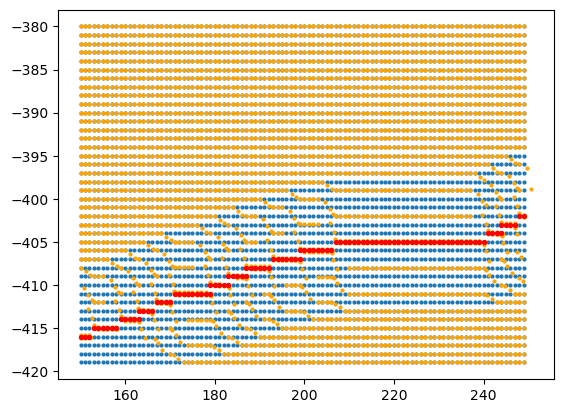

In [ ]:
warped_grid_patch = warped_grid[slice(380,420), slice(150,250), :]
regular_grid_patch = regular_grid[slice(380,420), slice(150,250), :]
edges = my_edge_map[patch]

N = 1
s = 4
plt.scatter(regular_grid_patch[::N, ::N, 1].ravel(), -regular_grid_patch[::N, ::N, 0].ravel(), s=s)
plt.scatter(warped_grid_patch[::N, ::N, 1].ravel(), -warped_grid_patch[::N, ::N, 0].ravel(), s=s, c='orange')
plt.scatter(warped_grid_patch[:, :, 1][edges], -warped_grid_patch[:, :, 0][edges], s=s*2, c='red')